In [1]:
import pandas as pd

In [62]:
attachments = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/letters/courteam_backlog_letters/data/llm_attachment_insert_final.csv")
tickets = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/letters/courteam_backlog_letters/data/llm_ticket_insert_final.csv")

In [3]:

from python_utilities.db_connection import DbConnection
import boto3
import json
import os
import pandas as pd
import ast

analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')
# Create session with specific profile
session = boto3.Session(profile_name='739275445236_DataScienceUser')
s3 = session.client('s3')

INFO [2026-07-16 17:51:30] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file
INFO [2026-07-16 17:51:30] - Found credentials in shared credentials file: ~/.aws/credentials


In [4]:
a_ids_to_fetch = attachments['attachment_id'].tolist()

query = f"""
SELECT *
FROM llm_attachments la
WHERE attachment_id IN ({','.join([f"'{a_id}'" for a_id in a_ids_to_fetch])})
"""
all_attachments = analytics_db.sql_to_df(query)


In [5]:
all_attachments.status.value_counts()

status
processed                    2615
rejected_too_long            1505
textract_failed                 1
irrelevant_file_extension       1
Name: count, dtype: int64

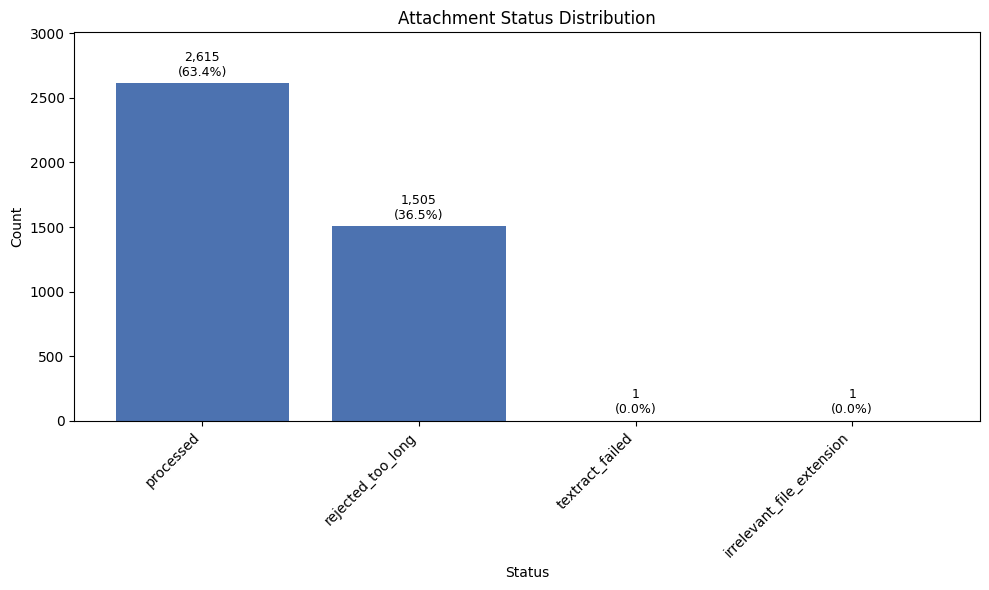

In [6]:
# plot value counts for status
import matplotlib.pyplot as plt

counts = all_attachments.status.value_counts()
total = counts.sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts.index.astype(str), counts.values, color='#4C72B0')

# annotate each bar with count and percentage
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center', va='bottom', fontsize=9,
    )

ax.set_title('Attachment Status Distribution')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [7]:
processed = all_attachments[all_attachments.status == 'processed']

In [8]:
processed

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket
0,3893911,fed4c582-fdf1-527c-aacb-9da854dc46eb,27262867171740-1,18501732,27262867171740,processed,combined_pdf_DR_II_1031_25_Information_Kontena...,pdf,2026-07-15 16:03:57,2026-07-15 12:04:34,ocr_source_files/letters/27262867171740-1.pdf,pair-email-classification
2,3893913,722bd0d7-11a1-5d52-bcdc-a83bf4d05681,27372456043548-1,18540147,27372456043548,processed,DR_II_458_26_An_Gl_Mitt_Ergebnis_Drittauskunft...,pdf,2026-07-15 16:03:11,2026-07-15 12:04:34,ocr_source_files/letters/27372456043548-1.pdf,pair-email-classification
4,3893910,18651eb3-15c0-5841-b5a5-6567cc16b500,28137211415452-1,18834086,28137211415452,processed,RB_004-12062026-082313.pdf,pdf,2026-07-15 16:03:13,2026-07-15 12:04:34,ocr_source_files/letters/28137211415452-1.pdf,pair-email-classification
5,3893909,8de3ccb2-fb15-5cbb-886c-50aeaf46842d,28205658438812-1,18858393,28205658438812,processed,4_DR_II_632_26_Erste_Mahnung_an_Kostenschuldne...,pdf,2026-07-15 16:03:15,2026-07-15 12:04:34,ocr_source_files/letters/28205658438812-1.pdf,pair-email-classification
6,3737733,d8d3a052-a70e-513e-aac8-443b7f4fb05c,28269659091356-1,18882071,28269659091356,processed,0_Sammel1.pdf,pdf,2026-06-18 13:52:46,2026-06-18 11:17:51,ocr_source_files/2026-06-18/zendesk_id_1888207...,pair-data-engineering-new
...,...,...,...,...,...,...,...,...,...,...,...,...
4117,3854544,10929b6a-939b-596d-be3a-8f3bb7517bdc,28787280233372-1,19072658,28787280233372,processed,Dokument_100326_09072026_09135020260709-182-iy...,pdf,2026-07-09 14:59:08,2026-07-09 11:18:31,ocr_source_files/2026-07-09/zendesk_id_1907265...,pair-data-engineering-new
4118,3854545,ce30ef5a-b0f1-518e-a796-214519da89bf,28787280433564-1,19072659,28787280433564,processed,DR-II_052126_Nachr_Nichtermittlung_08_07_20262...,pdf,2026-07-09 14:59:55,2026-07-09 11:18:33,ocr_source_files/2026-07-09/zendesk_id_1907265...,pair-data-engineering-new
4119,3854554,8a7ef91a-394f-5d13-987c-3e3cd8cbcb38,28787282083740-1,19072671,28787282083740,processed,DR_II_2706_26_An_Auftraggeber_Weiterleitung_Pf...,pdf,2026-07-09 14:59:13,2026-07-09 11:18:52,ocr_source_files/2026-07-09/zendesk_id_1907267...,pair-data-engineering-new
4120,3854555,40033f7e-9347-5c15-a9fc-a29db526a08d,28787295872668-1,19072672,28787295872668,processed,5636fb4cb87e48b420260709-182-13ya2t7.pdf,pdf,2026-07-09 14:59:15,2026-07-09 11:18:57,ocr_source_files/2026-07-09/zendesk_id_1907267...,pair-data-engineering-new


In [9]:
processed_atttachment_ids = processed['attachment_id'].tolist()

query_lap = f"""
SELECT *
FROM llm_attachments_predictions lap
WHERE attachment_id IN ({','.join([f"'{a_id}'" for a_id in processed_atttachment_ids])})
"""
processed_lap = analytics_db.sql_to_df(query_lap)

# processed egvp_intents

query_egvp_intents = f"""
SELECT *
FROM egvp_intents lei
WHERE attachment_id IN ({','.join([f"'{a_id}'" for a_id in processed_atttachment_ids])})
"""
processed_egvp_intents = analytics_db.sql_to_df(query_egvp_intents)

In [10]:
import sys
sys.path.append('/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation')
from utils.prod_utils import pivot_attachment_predictions

In [11]:
processed_lap_pivoted = pivot_attachment_predictions(processed_lap)

In [12]:
processed_lap_pivoted

,attachment_id,death_certificate_detection_confidence,death_certificate_detection_is_death_certificate,debt_counseling_attachment_attachment_type,debt_counseling_attachment_casefile_number,debt_counseling_attachment_counselling_slug,debt_counseling_attachment_counsellor_address,debt_counseling_attachment_counsellor_agency_name,debt_counseling_attachment_counsellor_email,debt_counseling_attachment_counsellor_firstname,...,pfub_aftercourt_type,pfub_class_pred,pfub_class_prob,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page
0,27262867171740-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.000,False,False,-1,False,False,none,-1
1,27372456043548-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.030,False,False,-1,False,False,none,-1
2,28137211415452-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.020,False,False,-1,False,False,none,-1
3,28205658438812-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.040,True,False,1,True,False,none,1
4,28269659091356-1,low,False,other,[],none,none,none,none,none,...,pfub_erlass,False,0.000,none,none,none,none,none,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2610,28787280233372-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.010,True,False,1,True,False,none,1
2611,28787280433564-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.010,True,False,1,True,False,none,1
2612,28787282083740-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.130,True,False,1,True,False,none,1
2613,28787295872668-1,none,none,none,none,none,none,none,none,none,...,pfub_erlass,False,0.855,False,False,-1,False,False,none,-1


In [13]:
processed_egvp_intents

,id,ticket_uuid,attachment_id,egvp_id,created_at,intents,ready_for_automation,status,retry,target_type,updated_at
0,41982,4a2e7362-bedd-5c91-b372-e4bd4cceb352,28289978613404-1,None,2026-06-19 08:39:45,"[{""params"": {""slug"": ""194705713098"", ""debtor_n...",1,sent,0,egvp,2026-06-19 08:39:45
1,42549,8be4c58d-ce98-5c67-9a3f-cb74b432fdfe,28346392098588-1,None,2026-06-22 11:38:22,"[{""params"": {""slug"": ""198413534092"", ""debtor_n...",1,sent,0,egvp,2026-06-22 11:38:22
2,42559,5aec68c9-43fe-5d2d-bcdd-be16b13d4c97,28346748421916-1,None,2026-06-22 13:10:37,"[{""params"": {""slug"": ""192263514577"", ""debtor_n...",1,sent,0,egvp,2026-06-22 13:10:37
3,42560,a7638a39-df55-5c53-ba14-71a91216fd13,28348232080924-1,None,2026-06-22 13:37:22,"[{""params"": {""slug"": ""168869943709"", ""debtor_n...",1,sent,0,egvp,2026-06-22 13:37:22
4,42561,ff0c3fa9-7a45-5d1d-8bcf-ce63a937e42c,28348471217692-1,None,2026-06-22 13:37:58,"[{""params"": {""slug"": ""181810127173"", ""debtor_n...",1,sent,0,egvp,2026-06-22 13:37:58
...,...,...,...,...,...,...,...,...,...,...,...
2429,69022,f4cf235a-5b63-54e3-ae63-6c230dd765a9,28550476312988-1,None,2026-07-15 16:57:34,"[{""params"": {""slug"": ""189371795734"", ""end_page...",0,sent,0,egvp,2026-07-15 16:57:34
2430,69023,f7386bc2-781d-568a-b9b6-5dd5648a2ce0,28548483235868-1,None,2026-07-15 16:57:35,"[{""params"": {""slug"": ""127052448975"", ""end_page...",0,sent,0,egvp,2026-07-15 16:57:35
2431,69024,fb1228ae-efd2-5eaf-a369-c5888df94a29,28548701341596-1,None,2026-07-15 16:57:37,"[{""params"": {""slug"": ""157550103228"", ""end_page...",0,sent,0,egvp,2026-07-15 16:57:37
2432,69025,fe12ad40-ca08-53e4-871d-98f0e3344860,28549029313564-1,None,2026-07-15 16:57:39,"[{""params"": {""slug"": ""149557978579"", ""end_page...",0,sent,0,egvp,2026-07-15 16:57:39


In [14]:
no_intents = processed_lap_pivoted[processed_lap_pivoted.attachment_id.isin(processed_egvp_intents['attachment_id'].tolist()) == False]

In [15]:
no_intents

,attachment_id,death_certificate_detection_confidence,death_certificate_detection_is_death_certificate,debt_counseling_attachment_attachment_type,debt_counseling_attachment_casefile_number,debt_counseling_attachment_counselling_slug,debt_counseling_attachment_counsellor_address,debt_counseling_attachment_counsellor_agency_name,debt_counseling_attachment_counsellor_email,debt_counseling_attachment_counsellor_firstname,...,pfub_aftercourt_type,pfub_class_pred,pfub_class_prob,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page
4,28269659091356-1,low,False,other,[],none,none,none,none,none,...,pfub_erlass,False,0.000000,none,none,none,none,none,none,none
5,28269659091356-2,low,False,settlement_plan_table,[1574],DR II 1574/26,none,none,none,none,...,pfub_erlass,False,0.000000,none,none,none,none,none,none,none
6,28269895678108-1,low,False,other,[187381148357],DR II 18/26,none,none,none,none,...,pfub_erlass,False,0.196667,none,none,none,none,none,none,none
7,28273966613404-1,low,False,other,[],none,"Bgm.-Aurnhammer-Str. 15, 86199 Augsburg",none,Lehle.GV@online.de,Claudia,...,pfub_erlass,False,0.000000,none,none,none,none,none,none,none
163,28298810922524-1,low,False,debt_settlement_plan_offer,[192162193101],Az.192162193101,"Spöttinger Str. 16, 86899 Landsberg am Lech",Gerichtsvollzieherin,brechenmacher@gvzentrale.de,Y,...,pfub_erlass,False,0.010000,none,none,none,none,none,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590,28783555781532-1,low,False,other,[195349158954],safe-sp1-1359986508223-012434992,"Rosengrund 7, 39130 Magdeburg",Pair Finance GmbH,rdaenhardt@gvzentrale.de,Ralph,...,pfub_erlass,False,0.150000,none,none,none,none,none,none,none
2591,28783555781532-2,low,False,other,[195349158954],none,"Rosengrund 7, 39130 Magdeburg",none,none,Dantrict,...,pfub_erlass,False,0.010000,none,none,none,none,none,none,none
2592,28783673895068-1,low,False,other,[],none,none,none,none,none,...,pfub_erlass,False,0.000000,none,none,none,none,none,none,none
2594,28784588103324-1,low,False,list_of_open_positions_request,[],DR II 833/26,"Allersberger Straße 185, Geb. C 1, 90461 Nürnberg","Nürnberg, Amtsgericht",murach@gvzentrale.de,Niko,...,pfub_erlass,False,0.010000,none,none,none,none,none,none,none


In [16]:
# this no intents are from zendesk email, so no egvp pipeleine run

In [17]:
processed_attachments_final = processed_egvp_intents.merge(processed_lap_pivoted, on='attachment_id', how='left')

In [18]:
processed_attachments_final

,id,ticket_uuid,attachment_id,egvp_id,created_at,intents,ready_for_automation,status,retry,target_type,...,pfub_aftercourt_type,pfub_class_pred,pfub_class_prob,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page
0,41982,4a2e7362-bedd-5c91-b372-e4bd4cceb352,28289978613404-1,None,2026-06-19 08:39:45,"[{""params"": {""slug"": ""194705713098"", ""debtor_n...",1,sent,0,egvp,...,pfub_erlass,False,0.00,none,none,none,none,none,none,none
1,42549,8be4c58d-ce98-5c67-9a3f-cb74b432fdfe,28346392098588-1,None,2026-06-22 11:38:22,"[{""params"": {""slug"": ""198413534092"", ""debtor_n...",1,sent,0,egvp,...,pfub_erlass,False,0.00,none,none,none,none,none,none,none
2,42559,5aec68c9-43fe-5d2d-bcdd-be16b13d4c97,28346748421916-1,None,2026-06-22 13:10:37,"[{""params"": {""slug"": ""192263514577"", ""debtor_n...",1,sent,0,egvp,...,pfub_erlass,False,0.00,none,none,none,none,none,none,none
3,42560,a7638a39-df55-5c53-ba14-71a91216fd13,28348232080924-1,None,2026-06-22 13:37:22,"[{""params"": {""slug"": ""168869943709"", ""debtor_n...",1,sent,0,egvp,...,pfub_erlass,False,0.02,none,none,none,none,none,none,none
4,42561,ff0c3fa9-7a45-5d1d-8bcf-ce63a937e42c,28348471217692-1,None,2026-06-22 13:37:58,"[{""params"": {""slug"": ""181810127173"", ""debtor_n...",1,sent,0,egvp,...,pfub_erlass,False,0.00,none,none,none,none,none,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429,69022,f4cf235a-5b63-54e3-ae63-6c230dd765a9,28550476312988-1,None,2026-07-15 16:57:34,"[{""params"": {""slug"": ""189371795734"", ""end_page...",0,sent,0,egvp,...,pfub_erlass,False,0.03,True,False,1,True,False,none,1
2430,69023,f7386bc2-781d-568a-b9b6-5dd5648a2ce0,28548483235868-1,None,2026-07-15 16:57:35,"[{""params"": {""slug"": ""127052448975"", ""end_page...",0,sent,0,egvp,...,pfub_erlass,False,0.00,True,False,1,True,False,none,1
2431,69024,fb1228ae-efd2-5eaf-a369-c5888df94a29,28548701341596-1,None,2026-07-15 16:57:37,"[{""params"": {""slug"": ""157550103228"", ""end_page...",0,sent,0,egvp,...,pfub_erlass,False,0.00,True,False,1,True,False,none,1
2432,69025,fe12ad40-ca08-53e4-871d-98f0e3344860,28549029313564-1,None,2026-07-15 16:57:39,"[{""params"": {""slug"": ""149557978579"", ""end_page...",0,sent,0,egvp,...,pfub_erlass,False,0.00,True,False,1,True,False,none,1


In [19]:
processed_attachments_final.ticket_uuid.is_unique

True

In [20]:
processed_attachments_final.attachment_id.is_unique

True

# Automation Analysis

INFO [2026-07-16 17:51:35] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO [2026-07-16 17:51:35] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


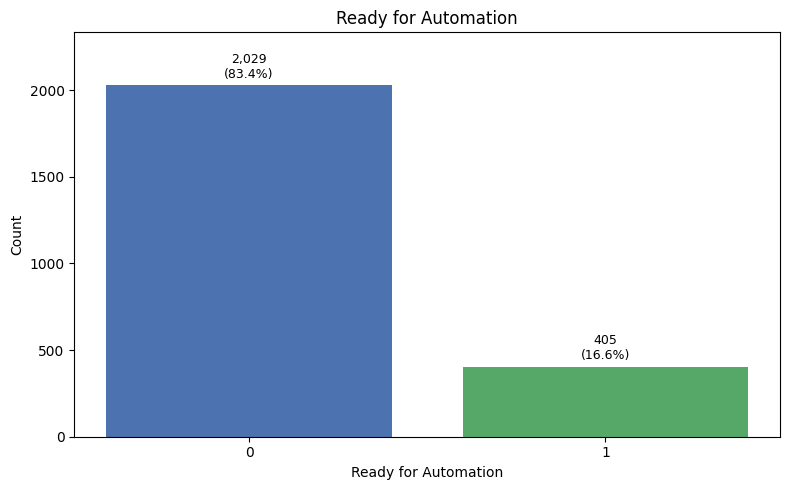

In [21]:
# plot value counts for ready_for_automation
import matplotlib.pyplot as plt

counts = processed_attachments_final.ready_for_automation.value_counts()
total = counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index.astype(str), counts.values, color=['#4C72B0', '#55A868'])

# annotate each bar with count and percentage
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center', va='bottom', fontsize=9,
    )

ax.set_title('Ready for Automation')
ax.set_xlabel('Ready for Automation')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [22]:
def find_how_automated(row):
    intent = row['intents']
    if intent:
        try:
            intent = intent.lower()
        except:
            return "none"
        if "ladung_va" in intent:
            return "ladung_va"
        elif "pfub_erlass" in intent:
            return "pfub_erlass"
        elif "vermogen" in intent:
            return "va"
        elif "dritt" in intent:
            return "dritt"
        elif '"aftercourt_type": "invoice"' in intent:
            return "invoice"
        else:
            return "none"
    else:
        return "none"
        

processed_attachments_final['how_automated'] = processed_attachments_final.apply(lambda row: find_how_automated(row) if row['ready_for_automation'] else 'none', axis=1)

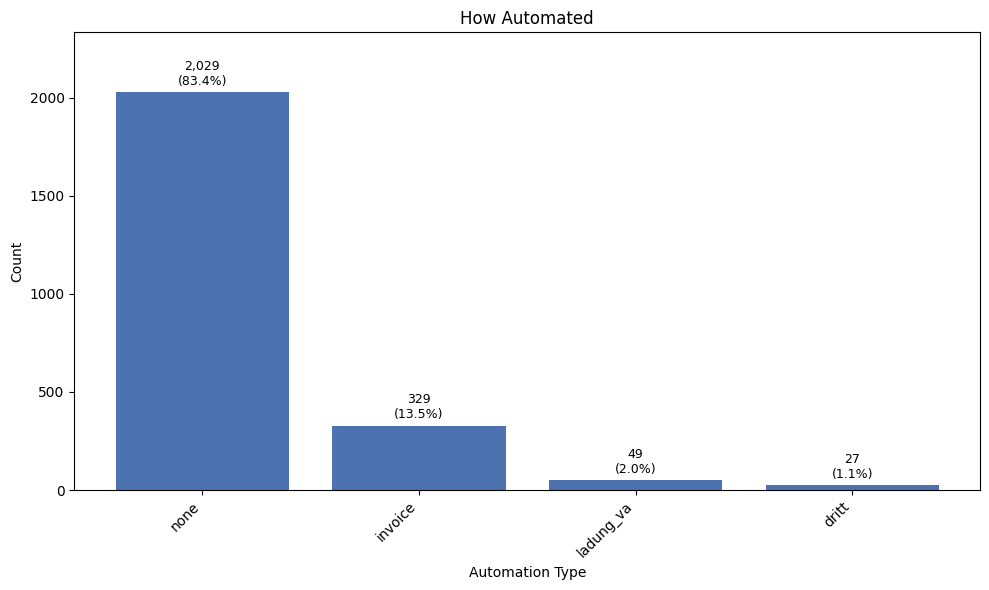

In [23]:
# plot value counts for how_automated
import matplotlib.pyplot as plt

counts = processed_attachments_final['how_automated'].value_counts()
total = counts.sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts.index.astype(str), counts.values, color='#4C72B0')

# annotate each bar with count and percentage
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center', va='bottom', fontsize=9,
    )

ax.set_title('How Automated')
ax.set_xlabel('Automation Type')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# detection analysis

In [24]:
def find_how_detected(row):
    intent = row['intents']
    if intent:
        try:
            intent = intent.lower()
        except:
            return "none"
        if "ladung_va" in intent:
            return "ladung_va"
        elif "pfub_erlass" in intent:
            return "pfub_erlass"
        elif "vermogen" in intent:
            return "va"
        elif "dritt" in intent:
            return "dritt"
        elif '"aftercourt_type": "invoice"' in intent:
            return "invoice"
        else:
            return "none"
    else:
        return "none"
        

processed_attachments_final['how_detected'] = processed_attachments_final.apply(lambda row: find_how_detected(row), axis=1)

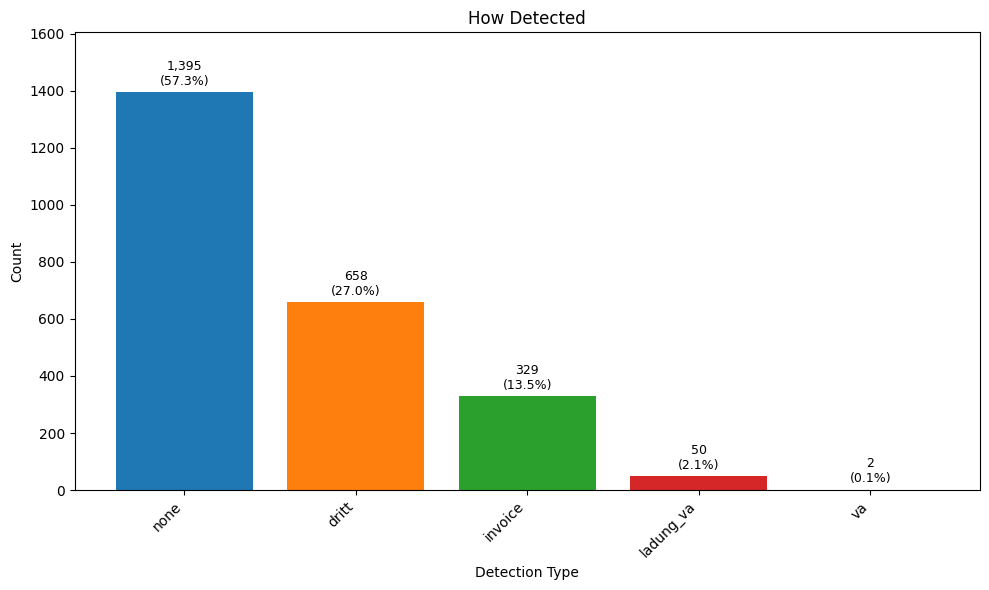

In [25]:
# plot value counts for how_detected
import matplotlib.pyplot as plt

counts = processed_attachments_final['how_detected'].value_counts()
total = counts.sum()

colors = plt.cm.tab10.colors  # distinct color per category

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts.index.astype(str), counts.values, color=colors[:len(counts)])

# annotate each bar with count and percentage
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center', va='bottom', fontsize=9,
    )

ax.set_title('How Detected')
ax.set_xlabel('Detection Type')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [26]:
# summary of total detected and automated
total_rows = len(processed_attachments_final)

detected = (processed_attachments_final['how_detected'] != 'none').sum()
automated = (processed_attachments_final['how_automated'] != 'none').sum()

print(f"Total Processed Attachments:  {total_rows:,}")
print(f"Detected:           {detected:,} ({detected / total_rows * 100:.1f}%)")
print(f"Automated:          {automated:,} ({automated / total_rows * 100:.1f}%)")



Total Processed Attachments:  2,434
Detected:           1,039 (42.7%)
Automated:          405 (16.6%)


In [27]:
processed_attachments_final

,id,ticket_uuid,attachment_id,egvp_id,created_at,intents,ready_for_automation,status,retry,target_type,...,pfub_class_prob,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page,how_automated,how_detected
0,41982,4a2e7362-bedd-5c91-b372-e4bd4cceb352,28289978613404-1,None,2026-06-19 08:39:45,"[{""params"": {""slug"": ""194705713098"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
1,42549,8be4c58d-ce98-5c67-9a3f-cb74b432fdfe,28346392098588-1,None,2026-06-22 11:38:22,"[{""params"": {""slug"": ""198413534092"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
2,42559,5aec68c9-43fe-5d2d-bcdd-be16b13d4c97,28346748421916-1,None,2026-06-22 13:10:37,"[{""params"": {""slug"": ""192263514577"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
3,42560,a7638a39-df55-5c53-ba14-71a91216fd13,28348232080924-1,None,2026-06-22 13:37:22,"[{""params"": {""slug"": ""168869943709"", ""debtor_n...",1,sent,0,egvp,...,0.02,none,none,none,none,none,none,none,ladung_va,ladung_va
4,42561,ff0c3fa9-7a45-5d1d-8bcf-ce63a937e42c,28348471217692-1,None,2026-06-22 13:37:58,"[{""params"": {""slug"": ""181810127173"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429,69022,f4cf235a-5b63-54e3-ae63-6c230dd765a9,28550476312988-1,None,2026-07-15 16:57:34,"[{""params"": {""slug"": ""189371795734"", ""end_page...",0,sent,0,egvp,...,0.03,True,False,1,True,False,none,1,none,dritt
2430,69023,f7386bc2-781d-568a-b9b6-5dd5648a2ce0,28548483235868-1,None,2026-07-15 16:57:35,"[{""params"": {""slug"": ""127052448975"", ""end_page...",0,sent,0,egvp,...,0.00,True,False,1,True,False,none,1,none,dritt
2431,69024,fb1228ae-efd2-5eaf-a369-c5888df94a29,28548701341596-1,None,2026-07-15 16:57:37,"[{""params"": {""slug"": ""157550103228"", ""end_page...",0,sent,0,egvp,...,0.00,True,False,1,True,False,none,1,none,dritt
2432,69025,fe12ad40-ca08-53e4-871d-98f0e3344860,28549029313564-1,None,2026-07-15 16:57:39,"[{""params"": {""slug"": ""149557978579"", ""end_page...",0,sent,0,egvp,...,0.00,True,False,1,True,False,none,1,none,dritt


In [28]:
processed_attachments_final.columns

Index(['id', 'ticket_uuid', 'attachment_id', 'egvp_id', 'created_at',
       'intents', 'ready_for_automation', 'status', 'retry', 'target_type',
       'updated_at', 'death_certificate_detection_confidence',
       'death_certificate_detection_is_death_certificate',
       'debt_counseling_attachment_attachment_type',
       'debt_counseling_attachment_casefile_number',
       'debt_counseling_attachment_counselling_slug',
       'debt_counseling_attachment_counsellor_address',
       'debt_counseling_attachment_counsellor_agency_name',
       'debt_counseling_attachment_counsellor_email',
       'debt_counseling_attachment_counsellor_firstname',
       'debt_counseling_attachment_counsellor_lastname',
       'debt_counseling_attachment_debtor_firstname',
       'debt_counseling_attachment_debtor_lastname',
       'debt_counseling_attachment_installment_plan_start_date',
       'debt_counseling_attachment_number_of_installments',
       'debt_counseling_attachment_settlement_amount_of

In [29]:
detection_cols = ['drittauskunft_egvp_is_dritt','egvp_standalone_invoice_invoice','ladung_class_pred','pfub_erlass_egvp_is_pfub','vermogenverzeichnis_egvp_is_va']

In [30]:
for col in detection_cols:
    if col in processed_attachments_final.columns:
        # count truthy values robustly (handles bool, 'True'/'False' strings and NaN)
        count = processed_attachments_final[col].astype(str).str.lower().isin(['true', '1']).sum()
        print(f"{col}: {count} ({count / total_rows * 100:.1f}%)")
    else:
        print(f"{col}: Column not found in DataFrame.")


drittauskunft_egvp_is_dritt: 658 (27.0%)
egvp_standalone_invoice_invoice: 332 (13.6%)
ladung_class_pred: 50 (2.1%)
pfub_erlass_egvp_is_pfub: 0 (0.0%)
vermogenverzeichnis_egvp_is_va: 2 (0.1%)


In [31]:
processed_attachments_final

,id,ticket_uuid,attachment_id,egvp_id,created_at,intents,ready_for_automation,status,retry,target_type,...,pfub_class_prob,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page,how_automated,how_detected
0,41982,4a2e7362-bedd-5c91-b372-e4bd4cceb352,28289978613404-1,None,2026-06-19 08:39:45,"[{""params"": {""slug"": ""194705713098"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
1,42549,8be4c58d-ce98-5c67-9a3f-cb74b432fdfe,28346392098588-1,None,2026-06-22 11:38:22,"[{""params"": {""slug"": ""198413534092"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
2,42559,5aec68c9-43fe-5d2d-bcdd-be16b13d4c97,28346748421916-1,None,2026-06-22 13:10:37,"[{""params"": {""slug"": ""192263514577"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
3,42560,a7638a39-df55-5c53-ba14-71a91216fd13,28348232080924-1,None,2026-06-22 13:37:22,"[{""params"": {""slug"": ""168869943709"", ""debtor_n...",1,sent,0,egvp,...,0.02,none,none,none,none,none,none,none,ladung_va,ladung_va
4,42561,ff0c3fa9-7a45-5d1d-8bcf-ce63a937e42c,28348471217692-1,None,2026-06-22 13:37:58,"[{""params"": {""slug"": ""181810127173"", ""debtor_n...",1,sent,0,egvp,...,0.00,none,none,none,none,none,none,none,ladung_va,ladung_va
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429,69022,f4cf235a-5b63-54e3-ae63-6c230dd765a9,28550476312988-1,None,2026-07-15 16:57:34,"[{""params"": {""slug"": ""189371795734"", ""end_page...",0,sent,0,egvp,...,0.03,True,False,1,True,False,none,1,none,dritt
2430,69023,f7386bc2-781d-568a-b9b6-5dd5648a2ce0,28548483235868-1,None,2026-07-15 16:57:35,"[{""params"": {""slug"": ""127052448975"", ""end_page...",0,sent,0,egvp,...,0.00,True,False,1,True,False,none,1,none,dritt
2431,69024,fb1228ae-efd2-5eaf-a369-c5888df94a29,28548701341596-1,None,2026-07-15 16:57:37,"[{""params"": {""slug"": ""157550103228"", ""end_page...",0,sent,0,egvp,...,0.00,True,False,1,True,False,none,1,none,dritt
2432,69025,fe12ad40-ca08-53e4-871d-98f0e3344860,28549029313564-1,None,2026-07-15 16:57:39,"[{""params"": {""slug"": ""149557978579"", ""end_page...",0,sent,0,egvp,...,0.00,True,False,1,True,False,none,1,none,dritt


# add text

In [32]:
from utils.prod_utils import get_text_by_attachment_id

In [33]:
processed_attachments_final['text'] = processed_attachments_final['attachment_id'].apply(
    lambda a_id: get_text_by_attachment_id(a_id, analytics_db, s3)
)

In [34]:
processed_attachments_final.to_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/letters/courteam_backlog_letters/data/processed_attachments_final_with_text.csv", index=False)

In [35]:
"""
Self-contained Drittauskunft parameter extractor.

Extracts: slug, no_result, bank_accounts, bak_to_iban from a document's text.
"""

import re
from collections import deque
from datetime import datetime
from typing import Any

import dateparser
from loguru import logger

# ---------------------------------------------------------------------------
# Regexes
# ---------------------------------------------------------------------------

# 12-15 digit number starting with '1'
SLUG_PATTERN = re.compile(r"\b1[0-9]{11,14}\b")

DATE_REGEX = re.compile(
    r"""(?x)
    (?<!\d)
    (?:
        (?:(?:0?[1-9]|[12]\d)|3[01])\s?[./:-][\s.]?(?:0?[13578]|1[02]|J(?:an(?:uar)?|uli?)|M(?:ärz?|ai)|Aug(?:ust)?|Dez(?:ember)?|Okt(?:ober)?)\s?(?:[./:-][\s.]?)?(?:[1-9]\d\d\d|\d\d)|
        (?:(?:0?[1-9]|[12]\d)|30)\s?[./:-][\s.]?(?:0?[13-9]|1[012]|J(?:an(?:uar)?|u[nl]i?)|M(?:ärz?|ai)|A(?:pr(?:il)?|ug(?:ust)?)|Sep(?:tember)?|(?:Nov|Dez)(?:ember)?|Okt(?:ober)?)\s?(?:[./:-][\s.]?)?(?:[1-9]\d\d\d|\d\d)|
        (?:0?[1-9]|[12]\d)\s?[./:-][\s.]?(?:0?2|Fe(?:b(?:ruar)?)?|(?:0?2|Feb(?:r(?:uar)?)?))\s?(?:[./:-][\s.]?)?(?:[1-9]\d(?:[02468][048]|[13579][26])|\d\d)|
        (?:0?[1-9]|[12][0-9])\s?[./:-][\s.]?(?:0?2|Fe(?:b(?:ruar)?)?|(?:0?2|Feb(?:r(?:uar)?)?))\s?(?:[./:-][\s.]?)?(?:[1-9]\d\d\d|\d\d)
    )
    (?!\d)""",
    re.IGNORECASE | re.VERBOSE,
)

NO_RESULT_PATTERN_1 = re.compile(
    r"\bkein(?:em|en|er|es|e)?\b"  # kein / keinem / keinen / keiner / keines / keine
    r"(?:\s+\w+){0,4}?"  # up to 4 optional words in between (e.g. "verwertbares")
    r"\s+ergebniss?(?:e|en|es)?\b",  # ergebnis / ergebnisse / ergebnissen / ergebnisses
    flags=re.IGNORECASE,
)

NO_RESULT_PATTERN_2 = re.compile(
    r"der\s+abruf\s+hat\s+zu\s+keinem\s+ergebnis\s+gef(?:ü|ue)hrt",
    re.IGNORECASE,
)

DRITTAUSKUNFT_BAK_NUMBER_REGEX = re.compile(
    r"\bbak\s*-\s*(?:nr|nummer)\.?:?\s*\d{6}\b", re.IGNORECASE
)

KONTOINHABER_REGEX = re.compile(r"\bkontoinhaber\b", re.IGNORECASE)

GENERAL_IBAN_REGEX = re.compile(
    r"\b[A-Z]{2}\d{2}(?:\s?[A-Z0-9]{4}){2,7}\s?[A-Z0-9]{1,3}\b",
    re.IGNORECASE,
)


# ---------------------------------------------------------------------------
# Slug extraction
# ---------------------------------------------------------------------------

def _is_valid_slug_context(text: str, match_start: int, match_end: int, window: int = 20) -> bool:
    """Filter out slugs that appear with dashes around them (e.g. -1XXXXXXXXXXXX-)."""
    context_start = max(0, match_start - window)
    context_end = min(len(text), match_end + window)
    context = text[context_start:context_end].lower()
    context = context.replace("\n", "").replace(" ", "")
    pattern = r"-1[0-9]{11,14}-"
    return not re.search(pattern, context)


def _select_best_slug(slug_candidates: list[str]) -> str | None:
    """Clean candidates; if all identical return the first, else the last one."""
    cleaned_slugs = [re.sub(r"\D", "", slug) for slug in slug_candidates]
    if not cleaned_slugs:
        return None
    if len(set(cleaned_slugs)) == 1:
        return cleaned_slugs[0]
    return cleaned_slugs[-1]


def extract_slug(text: str) -> str | None:
    """Extract a slug (12-15 digit number starting with 1) from the text."""
    if not text:
        return None

    matches = list(SLUG_PATTERN.finditer(text))
    if not matches:
        return None

    valid_slugs: list[str] = []
    for match in matches:
        if _is_valid_slug_context(text, match.start(), match.end()):
            valid_slugs.append(match.group())

    if not valid_slugs:
        return None

    return _select_best_slug(valid_slugs)


# ---------------------------------------------------------------------------
# No-result detection
# ---------------------------------------------------------------------------

def extract_no_result(text: str) -> bool:
    """Return True if the document contains a 'kein Ergebnis' style phrase."""
    if not text:
        return False
    match = NO_RESULT_PATTERN_1.search(text) or NO_RESULT_PATTERN_2.search(text)
    return match is not None


# ---------------------------------------------------------------------------
# Bank account (BAK number) extraction
# ---------------------------------------------------------------------------

def extract_bank_accounts(text: str) -> list[str]:
    """Extract unique 6-digit BAK numbers from a Drittauskunft document."""
    if not text:
        return []
    matches = DRITTAUSKUNFT_BAK_NUMBER_REGEX.findall(text)
    if not matches:
        return []
    unique_bak_numbers = {match[-6:] for match in matches}
    return sorted(unique_bak_numbers)


# ---------------------------------------------------------------------------
# BAK -> IBAN (with dates) extraction
# ---------------------------------------------------------------------------

def filter_bak_spans(match_objects: list[re.Match]) -> list[re.Match]:
    """Deduplicate BAK matches by their 6-digit number, keeping the first occurrence."""
    unique_baks: dict[str, re.Match] = {}
    unique_bak_spans: list[re.Match] = []
    for match in match_objects:
        bak_number_match = re.search(r"\d{6}", match.group())
        if bak_number_match:
            bak_number = bak_number_match.group()
            if bak_number not in unique_baks:
                unique_baks[bak_number] = match
                unique_bak_spans.append(match)
    return unique_bak_spans


def split_to_contexts(filtered_match_objects: list[re.Match], text: str) -> tuple[list[str], list[str]]:
    """Slice the text into one context window per BAK match."""
    window_size = 300
    if not filtered_match_objects:
        return [], []

    extracted_contexts: list[str] = []
    bak_numbers: list[str] = []

    for i in range(len(filtered_match_objects)):
        match_i = filtered_match_objects[i]
        match_j = filtered_match_objects[i + 1] if i + 1 < len(filtered_match_objects) else None
        if match_j:
            context_start = max(0, match_i.start())
            context_end = min(len(text), match_j.start())
            context = text[context_start:context_end]
            extracted_contexts.append(context)
            bak_number_match = re.search(r"\d{6}", match_i.group())
            if bak_number_match:
                bak_numbers.append(bak_number_match.group())
        else:
            # last span
            context_start = max(0, match_i.start())
            text_filtered = text[context_start:]
            last_kontinhaber_match = deque(KONTOINHABER_REGEX.finditer(text_filtered), maxlen=1)
            if last_kontinhaber_match:
                context_end = last_kontinhaber_match[0].start() + context_start
            else:
                context_end = context_start + window_size
            context = text[context_start:context_end]
            extracted_contexts.append(context)
            bak_number_match = re.search(r"\d{6}", match_i.group())
            if bak_number_match:
                bak_numbers.append(bak_number_match.group())
    return extracted_contexts, bak_numbers


def validate_iban(iban: str) -> bool:
    """Validate an IBAN using the standard mod-97 IBAN validation algorithm."""
    iban = iban.replace(" ", "").upper()
    if not (15 <= len(iban) <= 34):
        return False
    rearranged_iban = iban[4:] + iban[:4]
    numeric_iban = ""
    for char in rearranged_iban:
        if char.isdigit():
            numeric_iban += char
        else:
            numeric_iban += str(ord(char) - 55)  # A=10, B=11, ..., Z=35
    iban_int = int(numeric_iban)
    return iban_int % 97 == 1


def _normalize_iban(iban: str) -> str:
    """Canonical form used for uniqueness checks (no spaces, uppercase)."""
    return iban.replace(" ", "").upper()


def extract_date_from_context(context: str) -> datetime | None:
    """Extract the Errichtungsdatum from an IBAN subcontext (first parseable date)."""
    if not context:
        return None
    for match in DATE_REGEX.finditer(context):
        parsed = dateparser.parse(match.group(), languages=["de"])
        if parsed is not None:
            return parsed
    return None


def sort_ibans_by_date_desc(
    ibans: list[str], ibans_date: list[datetime | None]
) -> list[dict[str, str | None]]:
    """Order IBAN/creation-date pairs by Errichtungsdatum, newest first; undated last."""
    pairs = list(zip(ibans, ibans_date, strict=False))
    dated: list[tuple[str, datetime]] = [(iban, date) for iban, date in pairs if date is not None]
    dated.sort(key=lambda pair: pair[1], reverse=True)
    undated = [(iban, date) for iban, date in pairs if date is None]

    return [
        {"iban": iban, "date": date.strftime("%Y-%m-%d") if date is not None else None}
        for iban, date in (*dated, *undated)
    ]


def extract_iban_from_contexts(
    contexts: list[str], bak_numbers: list[str]
) -> dict[str, list[dict[str, str | None]]]:
    bak_to_iban: dict[str, list[dict[str, str | None]]] = {}
    seen_ibans: set[str] = set()
    for ctx, bak in zip(contexts, bak_numbers, strict=False):
        extracted_ibans: list[str] = []
        ibans_date: list[datetime | None] = []
        for iban in GENERAL_IBAN_REGEX.findall(ctx):
            if not validate_iban(iban):
                continue
            norm = _normalize_iban(iban)
            if norm in seen_ibans:
                continue
            # subcontext = starts with iban and ends with first next Kontoinhaber
            subcontext_start = ctx.find(iban)
            first_kontinhaber_match = next(KONTOINHABER_REGEX.finditer(ctx[subcontext_start:]), None)
            subcontext_end = (
                subcontext_start + first_kontinhaber_match.start()
                if first_kontinhaber_match
                else len(ctx)
            )
            extracted_date = extract_date_from_context(ctx[subcontext_start:subcontext_end])
            seen_ibans.add(norm)
            extracted_ibans.append(norm)
            ibans_date.append(extracted_date)

        bak_to_iban[bak] = sort_ibans_by_date_desc(extracted_ibans, ibans_date)
    return bak_to_iban


def extract_bak_to_iban(text: str) -> dict[str, list[dict[str, str | None]]]:
    """Extract a mapping of BAK numbers to their IBANs and creation dates."""
    if not text:
        return {}
    match_objects = list(DRITTAUSKUNFT_BAK_NUMBER_REGEX.finditer(text))
    filtered_match_objects = filter_bak_spans(match_objects)
    contexts, bak_numbers = split_to_contexts(filtered_match_objects, text)
    return extract_iban_from_contexts(contexts, bak_numbers)


# ---------------------------------------------------------------------------
# Top-level entry point
# ---------------------------------------------------------------------------

def extract_drittauskunft_parameters(text: str) -> dict[str, Any]:
    """
    Extract all Drittauskunft parameters from a document's text.

    Args:
        text: The document text to extract parameters from.

    Returns:
        Dict with keys: "slug", "no_result", "bank_accounts", "bak_to_iban".
    """
    try:
        slug = extract_slug(text)
    except Exception as e:  # noqa: BLE001
        logger.error(f"Error extracting slug from Drittauskunft document: {e}")
        slug = None

    try:
        no_result = extract_no_result(text)
    except Exception as e:  # noqa: BLE001
        logger.error(f"Error extracting no_result from Drittauskunft document: {e}")
        no_result = None

    try:
        bak_to_iban = extract_bak_to_iban(text)
    except Exception as e:  # noqa: BLE001
        logger.error(f"Error extracting bak_to_iban from Drittauskunft document: {e}")
        bak_to_iban = None

    try:
        bank_accounts = extract_bank_accounts(text)
    except Exception as e:  # noqa: BLE001
        logger.error(f"Error extracting bank_accounts from Drittauskunft document: {e}")
        bank_accounts = None

    # No explicit "kein Ergebnis" but also no bank accounts => treat as no result
    if no_result is False and bank_accounts == []:
        no_result = True

    return {
        "slug": slug,
        "no_result": no_result,
        "bank_accounts": bank_accounts,
        "bak_to_iban": bak_to_iban,
    }


In [36]:
processed_attachments_final['dritt_slug'], processed_attachments_final['dritt_no_result'], processed_attachments_final['dritt_bank_accounts'], processed_attachments_final['dritt_bak_to_iban'] = zip(*processed_attachments_final['text'].apply(extract_drittauskunft_parameters).apply(lambda x: (x['slug'], x['no_result'], x['bank_accounts'], x['bak_to_iban'])))

In [37]:
for idx, col in enumerate(processed_attachments_final.columns):
    print(f"{idx}: {col}")

0: id
1: ticket_uuid
2: attachment_id
3: egvp_id
4: created_at
5: intents
6: ready_for_automation
7: status
8: retry
9: target_type
10: updated_at
11: death_certificate_detection_confidence
12: death_certificate_detection_is_death_certificate
13: debt_counseling_attachment_attachment_type
14: debt_counseling_attachment_casefile_number
15: debt_counseling_attachment_counselling_slug
16: debt_counseling_attachment_counsellor_address
17: debt_counseling_attachment_counsellor_agency_name
18: debt_counseling_attachment_counsellor_email
19: debt_counseling_attachment_counsellor_firstname
20: debt_counseling_attachment_counsellor_lastname
21: debt_counseling_attachment_debtor_firstname
22: debt_counseling_attachment_debtor_lastname
23: debt_counseling_attachment_installment_plan_start_date
24: debt_counseling_attachment_number_of_installments
25: debt_counseling_attachment_settlement_amount_offer_to_us
26: drittauskunft_egvp_bank_accounts
27: drittauskunft_egvp_end_page
28: drittauskunft_egvp

11: death_certificate_detection_confidence
12: death_certificate_detection_is_death_certificate
13: debt_counseling_attachment_attachment_type
14: debt_counseling_attachment_casefile_number
15: debt_counseling_attachment_counselling_slug
16: debt_counseling_attachment_counsellor_address
17: debt_counseling_attachment_counsellor_agency_name
18: debt_counseling_attachment_counsellor_email
19: debt_counseling_attachment_counsellor_firstname
20: debt_counseling_attachment_counsellor_lastname
21: debt_counseling_attachment_debtor_firstname
22: debt_counseling_attachment_debtor_lastname
23: debt_counseling_attachment_installment_plan_start_date
24: debt_counseling_attachment_number_of_installments
25: debt_counseling_attachment_settlement_amount_offer_to_us

In [45]:
# if drittauskunft_egvp_is_dritt True and len(dritt_bank_accounts) == 0, then set dritt_no_result to True
dritt_no_result_condition = (processed_attachments_final['drittauskunft_egvp_is_dritt'] == 'True') & (processed_attachments_final['dritt_bank_accounts'].apply(lambda x: len(x) == 0))
num_changed = (dritt_no_result_condition & (processed_attachments_final['dritt_no_result'] != 'True')).sum()
processed_attachments_final.loc[dritt_no_result_condition, 'dritt_no_result'] = 'True'
print(f"Rows matching condition: {dritt_no_result_condition.sum()} | dritt_no_result changed to True: {num_changed}")

Rows matching condition: 133 | dritt_no_result changed to True: 133


/var/folders/ym/hcyz4chn3cq4n_8dslg5k50h0000gn/T/ipykernel_80716/3529089858.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  processed_attachments_final.loc[dritt_no_result_condition, 'dritt_no_result'] = 'True'


In [ ]:
# # automataion rules for drittauskunft
# 
# 1) no va should be inside AND
# 2) (no result) OR ONLY ONE BANK ACCOUNT FOUND (LEN(dritt_bank_accounts) == 1)
# 3) 

In [50]:
dritt_auto_before = processed_attachments_final['how_automated'].value_counts()['dritt']
dritt_auto_before

np.int64(27)

In [56]:
# 1) it sohuld be dritt
is_dritt_mask = processed_attachments_final['drittauskunft_egvp_is_dritt'] == 'True'
# 2) no va should be inside
is_va_inside_mask = processed_attachments_final['vermogenverzeichnis_egvp_is_va'] == 'False'
# 3) no invoice inside
is_invoice_inside_mask = processed_attachments_final['invoice_detection_egvp_is_invoice_inside'] == 'False'

# 4) No result OR only one bank account found
no_result_mask = processed_attachments_final['dritt_no_result'] == 'True'

only_one_bank_account_mask = processed_attachments_final['dritt_bank_accounts'].apply(lambda x: len(x) == 1)


automized_as_dritt_mask = is_dritt_mask & is_va_inside_mask & is_invoice_inside_mask & (no_result_mask | only_one_bank_account_mask)


In [57]:
automized_as_dritt_mask.sum()

np.int64(96)

In [59]:
# set how_automated and how_detected to dritt for the rows matching the automized_as_dritt_mask
automated_changed = (automized_as_dritt_mask & (processed_attachments_final['how_automated'] != 'dritt')).sum()
detected_changed = (automized_as_dritt_mask & (processed_attachments_final['how_detected'] != 'dritt')).sum()
processed_attachments_final.loc[automized_as_dritt_mask, 'how_automated'] = 'dritt'
processed_attachments_final.loc[automized_as_dritt_mask, 'how_detected'] = 'dritt'
print(f"Rows matching mask: {automized_as_dritt_mask.sum()} | how_automated changed to dritt: {automated_changed} | how_detected changed to dritt: {detected_changed}")

Rows matching mask: 96 | how_automated changed to dritt: 69 | how_detected changed to dritt: 0


In [60]:
processed_attachments_final

,id,ticket_uuid,attachment_id,egvp_id,created_at,intents,ready_for_automation,status,retry,target_type,...,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page,how_automated,how_detected,text,dritt_slug,dritt_no_result,dritt_bank_accounts,dritt_bak_to_iban
0,41982,4a2e7362-bedd-5c91-b372-e4bd4cceb352,28289978613404-1,None,2026-06-19 08:39:45,"[{""params"": {""slug"": ""194705713098"", ""debtor_n...",1,sent,0,egvp,...,none,none,none,ladung_va,ladung_va,Obergerichtsvollzieherin beim AG Eutin\n23701 ...,194705713098,True,[],{}
1,42549,8be4c58d-ce98-5c67-9a3f-cb74b432fdfe,28346392098588-1,None,2026-06-22 11:38:22,"[{""params"": {""slug"": ""198413534092"", ""debtor_n...",1,sent,0,egvp,...,none,none,none,ladung_va,ladung_va,Postanschrift\nGerichtsstraße 22\nBerenbrink\n...,198413534092,True,[],{}
2,42559,5aec68c9-43fe-5d2d-bcdd-be16b13d4c97,28346748421916-1,None,2026-06-22 13:10:37,"[{""params"": {""slug"": ""192263514577"", ""debtor_n...",1,sent,0,egvp,...,none,none,none,ladung_va,ladung_va,Tony Westphal\nSchützenstraße 24a\nGerichtsvol...,192263514577,True,[],{}
3,42560,a7638a39-df55-5c53-ba14-71a91216fd13,28348232080924-1,None,2026-06-22 13:37:22,"[{""params"": {""slug"": ""168869943709"", ""debtor_n...",1,sent,0,egvp,...,none,none,none,ladung_va,ladung_va,Anschrift\nObergerichtsvollzieher\nMarkus Meus...,168869943709,True,[],{}
4,42561,ff0c3fa9-7a45-5d1d-8bcf-ce63a937e42c,28348471217692-1,None,2026-06-22 13:37:58,"[{""params"": {""slug"": ""181810127173"", ""debtor_n...",1,sent,0,egvp,...,none,none,none,ladung_va,ladung_va,Obergerichtsvollzieherin\nBüroanschrift (GV-Bü...,181810127173,True,[],{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429,69022,f4cf235a-5b63-54e3-ae63-6c230dd765a9,28550476312988-1,None,2026-07-15 16:57:34,"[{""params"": {""slug"": ""189371795734"", ""end_page...",0,sent,0,egvp,...,False,none,1,none,dritt,"Obergerichtsvollzieherin\nAm Landgericht 8, 41...",189371795734,True,[],{}
2430,69023,f7386bc2-781d-568a-b9b6-5dd5648a2ce0,28548483235868-1,None,2026-07-15 16:57:35,"[{""params"": {""slug"": ""127052448975"", ""end_page...",0,sent,0,egvp,...,False,none,1,none,dritt,Oliver Zielasko\nDortmunder Straße 14\nOberger...,127052448975,False,[100005],"{'100005': [{'iban': 'DE04430400360200945402',..."
2431,69024,fb1228ae-efd2-5eaf-a369-c5888df94a29,28548701341596-1,None,2026-07-15 16:57:37,"[{""params"": {""slug"": ""157550103228"", ""end_page...",0,sent,0,egvp,...,False,none,1,none,dritt,Obergerichtsvollzieherin Katja Zock\nAmtsgeric...,157550103228,False,[157210],"{'157210': [{'iban': 'DE44100103001240985896',..."
2432,69025,fe12ad40-ca08-53e4-871d-98f0e3344860,28549029313564-1,None,2026-07-15 16:57:39,"[{""params"": {""slug"": ""149557978579"", ""end_page...",0,sent,0,egvp,...,False,none,1,none,dritt,M. Janßen\nElisabethstraße 8\nGerichtsvollzieh...,149557978579,False,[100758],"{'100758': [{'iban': 'DE55280501000092837277',..."


In [64]:
# add zendesk_id and comment_id using attachment_id
processed_attachments_final = processed_attachments_final.merge(
    attachments[['attachment_id', 'zendesk_id', 'comment_id']],
    on='attachment_id',
    how='left',
)
processed_attachments_final

,id,ticket_uuid,attachment_id,egvp_id,created_at,intents,ready_for_automation,status,retry,target_type,...,vermogenverzeichnis_egvp_start_page,how_automated,how_detected,text,dritt_slug,dritt_no_result,dritt_bank_accounts,dritt_bak_to_iban,zendesk_id,comment_id
0,41982,4a2e7362-bedd-5c91-b372-e4bd4cceb352,28289978613404-1,None,2026-06-19 08:39:45,"[{""params"": {""slug"": ""194705713098"", ""debtor_n...",1,sent,0,egvp,...,none,ladung_va,ladung_va,Obergerichtsvollzieherin beim AG Eutin\n23701 ...,194705713098,True,[],{},18887343,28289978613404
1,42549,8be4c58d-ce98-5c67-9a3f-cb74b432fdfe,28346392098588-1,None,2026-06-22 11:38:22,"[{""params"": {""slug"": ""198413534092"", ""debtor_n...",1,sent,0,egvp,...,none,ladung_va,ladung_va,Postanschrift\nGerichtsstraße 22\nBerenbrink\n...,198413534092,True,[],{},18901762,28346392098588
2,42559,5aec68c9-43fe-5d2d-bcdd-be16b13d4c97,28346748421916-1,None,2026-06-22 13:10:37,"[{""params"": {""slug"": ""192263514577"", ""debtor_n...",1,sent,0,egvp,...,none,ladung_va,ladung_va,Tony Westphal\nSchützenstraße 24a\nGerichtsvol...,192263514577,True,[],{},18901968,28346748421916
3,42560,a7638a39-df55-5c53-ba14-71a91216fd13,28348232080924-1,None,2026-06-22 13:37:22,"[{""params"": {""slug"": ""168869943709"", ""debtor_n...",1,sent,0,egvp,...,none,ladung_va,ladung_va,Anschrift\nObergerichtsvollzieher\nMarkus Meus...,168869943709,True,[],{},18903313,28348232080924
4,42561,ff0c3fa9-7a45-5d1d-8bcf-ce63a937e42c,28348471217692-1,None,2026-06-22 13:37:58,"[{""params"": {""slug"": ""181810127173"", ""debtor_n...",1,sent,0,egvp,...,none,ladung_va,ladung_va,Obergerichtsvollzieherin\nBüroanschrift (GV-Bü...,181810127173,True,[],{},18903513,28348471217692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429,69022,f4cf235a-5b63-54e3-ae63-6c230dd765a9,28550476312988-1,None,2026-07-15 16:57:34,"[{""params"": {""slug"": ""189371795734"", ""end_page...",0,sent,0,egvp,...,1,none,dritt,"Obergerichtsvollzieherin\nAm Landgericht 8, 41...",189371795734,True,[],{},18974095,28550476312988
2430,69023,f7386bc2-781d-568a-b9b6-5dd5648a2ce0,28548483235868-1,None,2026-07-15 16:57:35,"[{""params"": {""slug"": ""127052448975"", ""end_page...",0,sent,0,egvp,...,1,none,dritt,Oliver Zielasko\nDortmunder Straße 14\nOberger...,127052448975,False,[100005],"{'100005': [{'iban': 'DE04430400360200945402',...",18972685,28548483235868
2431,69024,fb1228ae-efd2-5eaf-a369-c5888df94a29,28548701341596-1,None,2026-07-15 16:57:37,"[{""params"": {""slug"": ""157550103228"", ""end_page...",0,sent,0,egvp,...,1,none,dritt,Obergerichtsvollzieherin Katja Zock\nAmtsgeric...,157550103228,False,[157210],"{'157210': [{'iban': 'DE44100103001240985896',...",18972830,28548701341596
2432,69025,fe12ad40-ca08-53e4-871d-98f0e3344860,28549029313564-1,None,2026-07-15 16:57:39,"[{""params"": {""slug"": ""149557978579"", ""end_page...",0,sent,0,egvp,...,1,none,dritt,M. Janßen\nElisabethstraße 8\nGerichtsvollzieh...,149557978579,False,[100758],"{'100758': [{'iban': 'DE55280501000092837277',...",18972997,28549029313564


In [65]:
cols_to_get = ["ticket_uuid", "zendesk_id", "comment_id", "attachment_id", "created_at", "how_automated", "how_detected", "intents", "dritt_bank_accounts", "dritt_bak_to_iban"]

In [66]:
final_backlog_results = processed_attachments_final[cols_to_get]

In [67]:
final_backlog_results

,ticket_uuid,zendesk_id,comment_id,attachment_id,created_at,how_automated,how_detected,intents,dritt_bank_accounts,dritt_bak_to_iban
0,4a2e7362-bedd-5c91-b372-e4bd4cceb352,18887343,28289978613404,28289978613404-1,2026-06-19 08:39:45,ladung_va,ladung_va,"[{""params"": {""slug"": ""194705713098"", ""debtor_n...",[],{}
1,8be4c58d-ce98-5c67-9a3f-cb74b432fdfe,18901762,28346392098588,28346392098588-1,2026-06-22 11:38:22,ladung_va,ladung_va,"[{""params"": {""slug"": ""198413534092"", ""debtor_n...",[],{}
2,5aec68c9-43fe-5d2d-bcdd-be16b13d4c97,18901968,28346748421916,28346748421916-1,2026-06-22 13:10:37,ladung_va,ladung_va,"[{""params"": {""slug"": ""192263514577"", ""debtor_n...",[],{}
3,a7638a39-df55-5c53-ba14-71a91216fd13,18903313,28348232080924,28348232080924-1,2026-06-22 13:37:22,ladung_va,ladung_va,"[{""params"": {""slug"": ""168869943709"", ""debtor_n...",[],{}
4,ff0c3fa9-7a45-5d1d-8bcf-ce63a937e42c,18903513,28348471217692,28348471217692-1,2026-06-22 13:37:58,ladung_va,ladung_va,"[{""params"": {""slug"": ""181810127173"", ""debtor_n...",[],{}
...,...,...,...,...,...,...,...,...,...,...
2429,f4cf235a-5b63-54e3-ae63-6c230dd765a9,18974095,28550476312988,28550476312988-1,2026-07-15 16:57:34,none,dritt,"[{""params"": {""slug"": ""189371795734"", ""end_page...",[],{}
2430,f7386bc2-781d-568a-b9b6-5dd5648a2ce0,18972685,28548483235868,28548483235868-1,2026-07-15 16:57:35,none,dritt,"[{""params"": {""slug"": ""127052448975"", ""end_page...",[100005],"{'100005': [{'iban': 'DE04430400360200945402',..."
2431,fb1228ae-efd2-5eaf-a369-c5888df94a29,18972830,28548701341596,28548701341596-1,2026-07-15 16:57:37,none,dritt,"[{""params"": {""slug"": ""157550103228"", ""end_page...",[157210],"{'157210': [{'iban': 'DE44100103001240985896',..."
2432,fe12ad40-ca08-53e4-871d-98f0e3344860,18972997,28549029313564,28549029313564-1,2026-07-15 16:57:39,none,dritt,"[{""params"": {""slug"": ""149557978579"", ""end_page...",[100758],"{'100758': [{'iban': 'DE55280501000092837277',..."


In [70]:
final_backlog_results.ticket_uuid.is_unique

True

In [71]:
final_backlog_results.zendesk_id.is_unique

True

In [72]:
final_backlog_results.comment_id.is_unique

True

In [69]:
final_backlog_results.attachment_id.is_unique

True

In [73]:
# plot how_automated and how_detected value counts with plotly
import plotly.express as px

plot_df = (
    pd.concat(
        [
            final_backlog_results['how_automated'].value_counts().rename_axis('category').reset_index(name='count').assign(metric='how_automated'),
            final_backlog_results['how_detected'].value_counts().rename_axis('category').reset_index(name='count').assign(metric='how_detected'),
        ]
    )
)

fig = px.bar(
    plot_df,
    x='category',
    y='count',
    color='metric',
    barmode='group',
    text='count',
    title='How Automated vs How Detected',
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Type', yaxis_title='Count')
fig.show()

In [74]:
final_backlog_results.to_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/letters/courteam_backlog_letters/data/final_backlog_results.csv", index=False)